# 最尤推定を用いたポアソン回帰

書籍においては、ポアソン回帰のモデリングにベイズ推定（ベイズ統計モデリング）を用いていました。これはベイズ推定出ないとモデリングできないことを意味するわけではなく、Statsmodelsを用いた最尤推定でもモデリング可能です。

この最尤推定を用いたポアソン回帰による異常検知を、Python（Statsmodels）を用いて以下の手順で実装する方法を解説します。

- A. 説明変数の選択
- B. モデルの学習
- C. 推論

なおデータセットにはベイズ推定（[ch8_6_Poisson_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch8_6_Poisson_Regression.ipynb)）と同じ地震と火山のデータを、ターゲットとする誤報率としては0.0027を採用します。

使用するデータの例を以下に再掲します。

```csv
country,year,earthquakes,active_since_1800
Afghanistan,2018,1,0
Afghanistan,2019,1,0
Afghanistan,2022,1,0
Albania,2019,1,0
Algeria,2021,1,0
Argentina,2019,2,6
Argentina,2020,1,6
Argentina,2021,3,6
Argentina,2022,2,6
Australia,2019,1,2
:
```

`country`列が国名、`year`列が粘土、`active_since_1800`列が1800年以降に噴火した火山の数、`earthquakes`列がマグニチュード6以上の年間地震発生数$x$を表しており、2018年から2022年までの5年分のデータを学習用、2023年のデータを推論用として用います。

## A. 説明変数の選択

ベイズ推定を用いたポアソン回帰モデル（[ch8_6_Poisson_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch8_6_Poisson_Regression.ipynb)）と同様のため、省略します。

火山数と平均地震発生数には相関があるという分析に基づき、火山数`active_since_1800`を説明変数$x$、年間地震発生数`earthquakes`を$y$として以下のようなポアソン回帰モデルを構築します。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&\eta=w_1 x+w_0  \nonumber \\
&\log(\mu)=\eta  \nonumber \\
&p(y \mid \boldsymbol{x}, \boldsymbol{w}, w_0) = Po(\mu)
\end{align}
" />

## B. モデルの学習

ポアソン回帰モデルの最尤推定による学習を実施します（ポアソン回帰ではしきい値の算出に推論データの説明変数$\boldsymbol{x}$が必要となるため、学習段階ではしきい値算出を実施しません）。

statsmodelsで確率分布やリンク関数をカスタマイズしながらGLMを実装するには、[statsmodels.genmod.generalized_linear_model.GLM](https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html)クラスを使用し、`family`引数に確率分布やリンク関数を指定するクラスを渡します。確率分布は[statsmodels.genmod.families.family](https://www.statsmodels.org/stable/glm.html#families)から、リンク関数は[statsmodels.genmod.families.links](https://www.statsmodels.org/stable/glm.html#link-functions)から該当するクラスを選択します。

In [6]:
# 最尤推定による二項ロジスティック回帰の実装例（学習）
import pandas as pd
import numpy as np
import statsmodels.api as sm

###### 学習データの読み込みと前処理######
# 学習データ読込
df_train = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/earthquakes_volcanoes_2018-2022.csv')
# 学習データの説明変数x、応答変数yを別々に保持してndarray化
x_train = df_train['active_since_1800'].to_numpy()
y_train = df_train['earthquakes'].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
X_train_intercept = sm.add_constant(x_train) # 切片を追加
family=sm.families.Poisson() # 確率分布（ポアソン分布）を指定
mod = sm.GLM(y_train, X_train_intercept, family=family) # ポアソン回帰モデルを作成
res = mod.fit() # モデルの学習を実行

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
# 学習段階ではしきい値を求めない

###### 学習で求めたパラメータをすべて表示######
w_0 = res.params[mod.exog_names.index('const')]
w_1 = res.params[mod.exog_names.index('x1')]
print(f'w_1={w_1}')
print(f'w_0={w_0}')

# 学習結果のサマリーの表示
print(res.summary())

w_1=0.04411544550236099
w_0=-0.4908740053050406
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  455
Model:                            GLM   Df Residuals:                      453
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -652.67
Date:                Fri, 02 Jan 2026   Deviance:                       898.65
Time:                        02:44:53   Pearson chi2:                 1.31e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.7704
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
cons

パラメータの推定値（切片$w_0$に相当する`const`および傾き$w_1$に相当する`x1`）が、ベイズ推定（[ch8_6_Poisson_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch8_6_Poisson_Regression.ipynb)）の事後分布の平均とほぼ等しくなっていることが分かります。

説明変数（火山数）$x$と期待発生回数（平均地震発生数）$\mu$の予測値との関係をプロットしてみます。

<Axes: xlabel='active_since_1800', ylabel='earthquakes'>

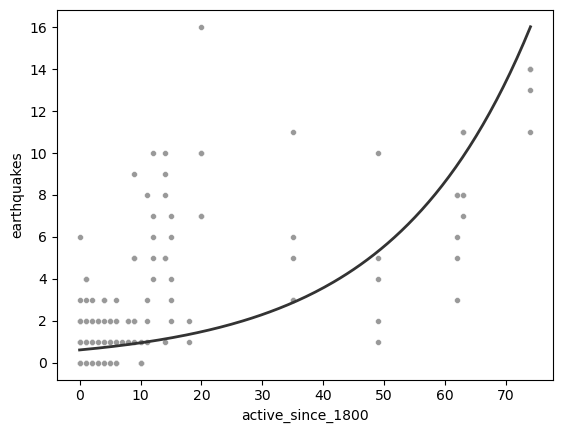

In [7]:
# 火山数xと平均地震発生数μの予測値の関係を可視化
import seaborn as sns
import matplotlib.pyplot as plt

# 学習データからxとmu範囲を決定
x_min, x_max = df_train['active_since_1800'].min(), df_train['active_since_1800'].max()
mu_min, mu_max = df_train['earthquakes'].min(), df_train['earthquakes'].max()
# muの推定値を計算してプロット
x_line = np.linspace(x_min, x_max, num=200)
rho_line = w_0 + w_1*x_line
mu_line = np.exp(rho_line)
plt.plot(x_line, mu_line, color='#333333', linewidth=2)
###### 学習データを散布図で描画 ######
sns.scatterplot(data=df_train,
                x='active_since_1800', y='earthquakes',
                c='#999999', s=18, marker="o")

データにうまくフィットした$\mu$の予測ができていそうです。


## C. 推論

推論フェーズでは、学習フェーズで求めたパラメータ$w_1,w_0$、および推論データの説明変数$\boldsymbol{x}$、応答変数$y$を用いて、以下の推論手順に従い異常判定を実施します。

- 学習で得たパラメータ$w_1,w_0$と推論データの説明変数$x$から、モデル式に基づき予測分布を求める。
- 予測分布の分位点とターゲットとする誤報率に基づき、応答変数yの上下のしきい値を求める
- 推論データの応答変数$y$が、このしきい値の範囲外にあれば異常あり、範囲内にあれば異常なしと判定する

このフローを以下のように実装します。

In [8]:
# 最尤推定による二項ロジスティック回帰の実装例（推論）
from scipy import stats

###### 学習したパラメータをここに記載 ######
W_1=0.04411544550236099  # 線形予測子の係数パラメータ
W_0=-0.4908740053050406  # 線形予測子の切片パラメータ
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）

###### 推論データの読み込みと前処理 ######
# 火山数と地震の発生回数データ
df_inference = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/earthquakes_volcanoes_2023.csv')
# 学習データの説明変数x、応答変数yを別々に保持してndarray化
x_inference = df_inference['active_since_1800'].to_numpy()
y_inference = df_inference['earthquakes'].to_numpy()

###### 推論を実行 ######
# 線形予測子rhoの計算
rho_inference = W_0 + W_1 * x_inference
# 期待発生回数μの計算
mu_inference = np.exp(rho_inference)
# 下側しきい値（ポアソン分布の累積分布関数から計算）
th_lowers = stats.poisson.ppf(TARGET_FP_RATE/2, mu=mu_inference)
# 上側しきい値（ポアソン分布の累積分布関数から計算）
th_uppers = stats.poisson.ppf(1 - TARGET_FP_RATE/2, mu=mu_inference)
# しきい値により異常の有無を判定
predictions = np.where((y_inference < th_lowers) | (y_inference > th_uppers),
                       "anomaly", "normal")
# 推論結果を表示（しきい値を超えた国）
df_inference['prediction'] = predictions
print(df_inference[df_inference['prediction'] == 'anomaly'][
    ['country', 'year', 'earthquakes', 'active_since_1800']].sort_values(
    'earthquakes', ascending=False).reset_index(drop=True))

            country  year  earthquakes  active_since_1800
0       Philippines  2023           15                 14
1  Papua New Guinea  2023           10                 20
2             Tonga  2023            8                 15
3           Vanuatu  2023            8                 12
4         Argentina  2023            7                  6
5       Afghanistan  2023            6                  0
6       New Zealand  2023            6                  9
7            Turkey  2023            6                  2


これらの国は2023年に、火山数から予測されるよりも多くの地震が、偶然の範囲を超えて発生したと言えます。

推論の結果、異常と判定される範囲を推論データと重ねて可視化してみます。

Text(0, 0.5, 'earthquakes')

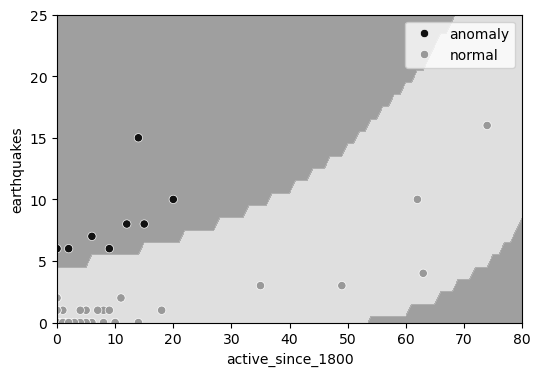

In [9]:
# 正常と異常の境界をプロット
import matplotlib.cm as cm
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# (x,y)格子点を作成
x_grid = np.linspace(0, 80, num=81)
y_grid = np.arange(0, 26)
X, Y = np.meshgrid(x_grid, y_grid)
# 線形予測子rhoの計算
rho_grid = W_0 + W_1 * x_grid
# 期待発生回数μの計算
mu_grid = np.exp(rho_grid)
# xの値ごとに予測分布を計算
pred_all_grid = []
for x_idx, x_i in enumerate(x_grid):
    # 下側しきい値（ポアソン分布の累積分布関数から計算）
    th_lower = stats.poisson.ppf(TARGET_FP_RATE/2, mu=mu_grid[x_idx])
    # 上側しきい値（ポアソン分布の累積分布関数から計算）
    th_upper = stats.poisson.ppf(1 - TARGET_FP_RATE/2, mu=mu_grid[x_idx])
    # しきい値判定
    pred = np.where((Y[:, x_idx] < th_lower) | (Y[:, x_idx] > th_upper), 0, 1)
    pred_all_grid.append(pred)
pred_all_pivot = np.array(pred_all_grid).T
# 確率質量をプロット
ax.contourf(X, Y, pred_all_pivot, levels=1, cmap=cm.gray, alpha=0.5)
###### 推論データを散布図で描画 ######
sns.scatterplot(x=x_inference, y=y_inference, hue=predictions,
                palette=['#111111', '#999999'], ax=ax)
ax.set_xlabel('active_since_1800')
ax.set_ylabel('earthquakes')

火山の数が多いほど、地震発生数における正常と異常の境界が高頻度側にシフトしていることがわかります。